In [8]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2


In [9]:
import os
import sys

current_dir = os.path.dirname(os.path.abspath('.'))
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

In [10]:
from tomopt.volume import Volume

from detector_config import get_layers
from utils import draw

In [11]:
volume = Volume(get_layers(panel_z_spacing=0.01, n_panels=3, init_gap=0., init_res=5000, smooth=0.01))


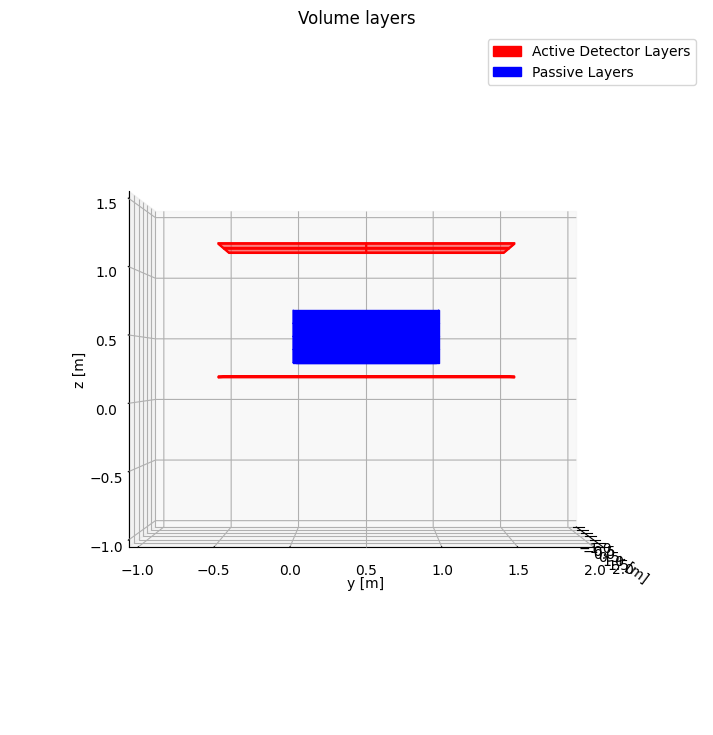

In [12]:
draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

In [13]:
from functools import partial
import torch
from co_design_optimization.wrapper import CoDesignVolumeWrapper
from co_design_optimization.utility_loss import HypothesisTestLoss

wrapper = CoDesignVolumeWrapper(
    volume,
    # xy_pos_opt=partial(torch.optim.SGD, lr=0),
    # xy_span_opt=partial(torch.optim.SGD, lr=0),
    # z_pos_opt=partial(torch.optim.SGD, lr=1e-3),
    # gap_opt=partial(torch.optim.SGD, lr=0),
    # sigma_soft_opt=partial(torch.optim.SGD, lr=1e-3),
    xy_pos_opt    = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    xy_span_opt   = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    z_pos_opt     = partial(torch.optim.AdamW, lr=1e-2, weight_decay=0),
    gap_opt       = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    log_sigma_sw_opt= partial(torch.optim.AdamW, lr=1e-2, weight_decay=0),

    loss_func = HypothesisTestLoss(
        alpha=0.05,
        beta=200.0,
        #tau_q= 0.0001,
        tau_detect=20,
        debug=True,
        init_sigma_sw=0.008,
        tau_p=0.1,
        n_bins = 50,
    ),

)

In [14]:
from torch import Tensor
from tomopt.core import X0
from tomopt.optimisation.data import PassiveYielder

bkg_mat = 'aluminium'
block_mat = 'uranium'

def cubes_rad_length(*, z: float, lw: Tensor, size: float, signal: bool = False) -> Tensor:
    rad_length = torch.ones(list((lw / size).long())) * X0[bkg_mat]
    grid = torch.zeros_like(rad_length)

    cube_size = 1
    offset = 2
    if signal and (z > 0.3 and z < 0.5):
        grid[-offset - cube_size : -offset, offset : offset + cube_size] = X0[block_mat]
        rad_length[grid.bool()] = grid[grid.bool()]

    return rad_length

n_samples = 50
# Create passive material for the volume
passives = PassiveYielder([lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples 
                           #+[lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                           #+[lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                           #+ [lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                          ,shuffle=False)

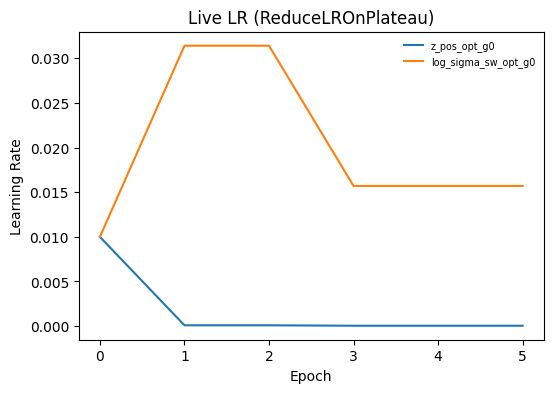

[0.9069260358810425, 0.9196406602859497, 0.9544563293457031, 0.9443939328193665, 0.8841325044631958, 0.9869329333305359]


In [ ]:
from tomopt.optimisation import OptConfig, MuonResampler
from callbacks import SigmoidPanelSmoothnessSchedule
from co_design_optimization.callbacks import PlotLoss, ClipSigmaSoftGrad, HypothesisTestCallback, LiveLrPlotCallback, OneCycle, ReduceLROnPlateauCallback, ReduceLRResponsible

_ = wrapper.fit(n_epochs=20,  # Run for 10 epochs (5+5 are warmup epochs)""
                passive_bs=2*n_samples,  # Update every passive volumes (we only have one)
                n_mu_per_volume=2000,  # Use 1000 per passive volume
                mu_bs=1000,  # Run the 1000 muons per volume in 10 batchesnomorenans' of 100 muons (quicker than a single batch of 1000)
                trn_passives=passives,
                val_passives=None, #passives,  # Evaluate on the training data
                cbs=[ HypothesisTestCallback(),
                   OptConfig(n_warmup=2, rates={'xy_pos_opt':0.0, 'z_pos_opt':0.01, 'xy_span_opt':0.0, 'gap_opt':0.0, 'log_sigma_sw_opt':0.01}),
                    MuonResampler(),
                    #OneCycle('z_pos_opt', init_lr= 0.001, mid_lr=0.01, final_lr= 0.001, warmup_length=5),
                    #OneCycle('sigma_soft_opt', init_lr= 0.01, mid_lr=0.02, final_lr= 0.0001, warmup_length=5),
                    #SigmoidPanelSmoothnessSchedule((0.1, 0.001))
                    ReduceLROnPlateauCallback(),
                    #ReduceLRResponsible(patience=5),
                    PlotLoss(save_path='plots/loss'),
                    ClipSigmaSoftGrad()
                    ]) 

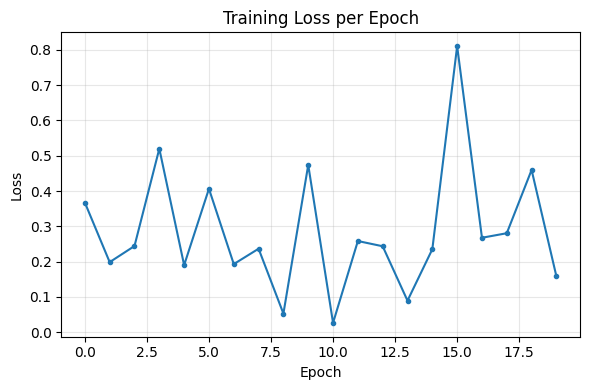

In [ ]:
wrapper.plot_train_loss()


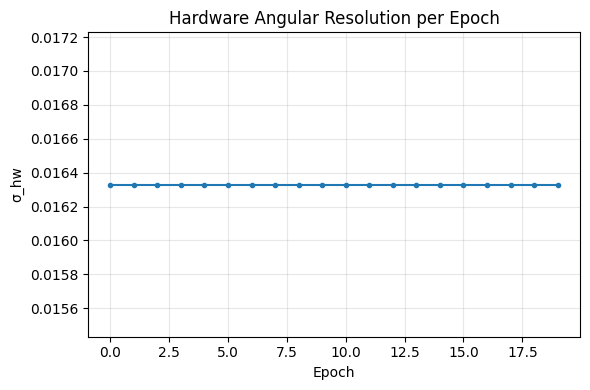

In [ ]:
wrapper.plot_sigma_hw()



In [ ]:
wrapper.plot_log_sigma_sw()

AttributeError: 'CoDesignVolumeWrapper' object has no attribute 'plot_log_sigma_sw'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sig_hw   = np.array(wrapper.history['sigma_hw'])
sig_soft = np.exp(np.array(wrapper.history['log_sigma_sw']))
power     = 1-np.array(wrapper.history['train_loss'])

# Grid for contour
nx = ny = 60
xg = np.linspace(sig_hw.min(), sig_hw.max(), nx)
yg = np.linspace(sig_soft.min(), sig_soft.max(), ny)
X, Y = np.meshgrid(xg, yg)

# Interpolate loss onto grid (very light nearest-neighbour)
from scipy.interpolate import griddata
Z = griddata(
    points=np.column_stack([sig_hw, sig_soft]),
    values=power,
    xi=(X, Y),
    method="linear"
)

plt.figure(figsize=(7,6))

# background histogram
plt.hist2d(sig_hw, sig_soft, bins=30, cmap="viridis", alpha=0.5)

# loss contours
cs = plt.contour(X, Y, Z, levels=10, linewidths=1.2)
plt.clabel(cs, inline=True, fontsize=8)


plt.xlabel("sigma_hw")
plt.ylabel("log_sigma_soft")
plt.title("utility contours over training")
plt.tight_layout()
plt.show()


TypeError: '<=' not supported between instances of 'NoneType' and 'NoneType'

In [ ]:

sig_hw   = np.array(wrapper.history['sigma_hw'])
sig_soft = np.exp(np.array(wrapper.history['log_sigma_soft']))
power     = 1-np.array(wrapper.history['val_loss'])

# Grid for contour
nx = ny = 60
xg = np.linspace(sig_hw.min(), sig_hw.max(), nx)
yg = np.linspace(sig_soft.min(), sig_soft.max(), ny)
X, Y = np.meshgrid(xg, yg)

# Interpolate loss onto grid (very light nearest-neighbour)
from scipy.interpolate import griddata
Z = griddata(
    points=np.column_stack([sig_hw, sig_soft]),
    values=power,
    xi=(X, Y),
    method="linear"
)
plt.figure(figsize=(7,6))

# background histogram
plt.hist2d(sig_hw, sig_soft, bins=30, cmap="viridis", alpha=0.4)

# continuous filled contour
cs = plt.contourf(X, Y, Z, levels=50, cmap="magma")  # more levels = smoother

# colorbar
cbar = plt.colorbar(cs)
cbar.set_label("power")

plt.xlabel("sigma_hw")
plt.ylabel("sigma_sw")
plt.title("utility contours over training")
plt.tight_layout()
plt.show()




KeyError: 'log_sigma_soft'

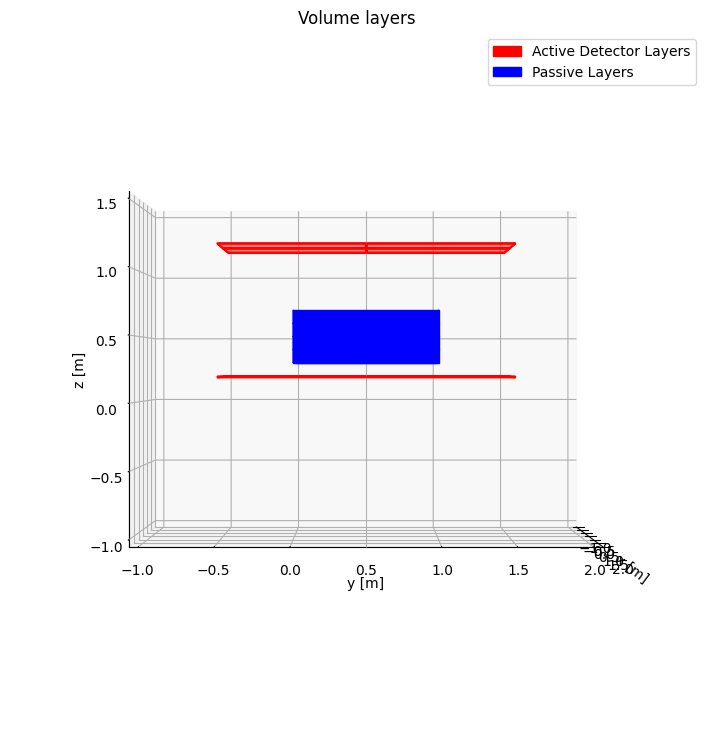

In [ ]:
draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

In [ ]:
sigmas = torch.logspace(-3, 0, 20)  # e.g. 0.001 → 1.0
values = []
loss_func = wrapper.loss_func
wrapper._scan_volumes(passives)
for s in sigmas:
    loss_func.log_sigma_soft.data = torch.log(s)
    with torch.no_grad():
        loss = loss_func()
    values.append(loss.item())


AttributeError: 'NoneType' object has no attribute 'state'